In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/powerlifting.db')

# Shape
pd.read_sql("SELECT COUNT(*) as total_rows FROM meets", engine)

,total_rows
0,3907789


In [3]:
# Equipment Types
pd.read_sql("""
SELECT equipment, COUNT(*) as count
FROM meets
GROUP BY equipment
ORDER BY count DESC
""", engine)

,Equipment,count
0,Raw,1831773
1,Single-ply,1386621
2,Unlimited,323350
3,Wraps,235624
4,Multi-ply,130305
5,Straps,116


In [4]:
# Completeness of key columns
pd.read_sql("""
SELECT
    COUNT(*) as total,
    COUNT(Age) as has_age,
    COUNT(BodyweightKg) as has_bodyweight,
    COUNT(TotalKg) as has_total
FROM meets
""", engine)

,total,has_age,has_bodyweight,has_total
0,3907789,2456780,3863576,3642268


In [5]:
# Sex Breakdown
pd.read_sql("""
SELECT Sex, COUNT(*) as count
FROM meets
GROUP BY Sex
""", engine)

,Sex,count
0,F,1090584
1,M,2817039
2,Mx,166


# Initial Data Cleaning Decisions
Raw is the largest category with 1.8M rows. For now, I'll filter to RAW only

Age - 63% of the entries have age recorded. This is the most significant issue with missing data, and we'll solve it by filtering the rows with missing ages out for now. 

Total - Missing total's are negligible.

Sex - 166 Mx entries are a negligible part of the data set. I'll filter them out.

Mention these decisions in README.

In [6]:
# Check Place column - filter out DQs
pd.read_sql("""
SELECT Place, COUNT(*) as count
FROM meets
WHERE Equipment = 'Raw'
GROUP BY Place
ORDER BY count DESC
LIMIT 15
""", engine)

,Place,count
0,1,912481
1,2,298524
2,3,160506
3,4,98378
4,DQ,66053
5,5,65673
6,6,45995
7,7,33330
8,8,24895
9,9,18957


In [7]:
# Check Event types - want full SBD
pd.read_sql("""
SELECT Event, COUNT(*) as count
FROM meets
WHERE Equipment = 'Raw'
GROUP BY Event
ORDER BY count DESC
""", engine)

,Event,count
0,SBD,1122435
1,B,479308
2,D,158879
3,BD,60846
4,S,9273
5,SD,585
6,SB,447


In [8]:
# Age distribution after filtering to Raw, valid total, valid age
pd.read_sql("""
SELECT
    MIN(Age) as min_age,
    MAX(Age) as max_age,
    AVG(Age) as avg_age
FROM meets
WHERE Equipment = 'Raw'
    AND TotalKg IS NOT NULL
    AND Age IS NOT NULL
""", engine)

,min_age,max_age,avg_age
0,0.0,105.5,30.702931


# Further Data Cleaning Decisions
Filter out "DQ" and "G" to get numeric places only (for completed, valid lifts)

Filter event to SBD only

Min and max ages at 0.0 and 105.5 are unrealistic and data quality issues. Average age is 30.7 which seems reasonable (though maybe slightly inflated?). Age cap to something like 14-80. 

**load_clean_data** function handles these decisions, see "src/clean_data.py" for details.

In [2]:
import os
import sys

# Set project root explicitly using the absolute path
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append('..')

print(f"Working directory: {os.getcwd()}")
print(f"Contents: {os.listdir('.')}")

Working directory: /Users/lawrence/pl-predictor
Contents: ['app', 'environment.yml', 'models', 'README.md', '.gitignore', '.git', 'data', 'outputs', 'notebooks', 'src']


In [3]:
from src.clean_data import load_clean_data

df = load_clean_data()
df.describe()

Clean dataset: 900,009 rows


,Age,BodyweightKg,TotalKg
count,900009.000000,900009.000000,900009.000000
mean,28.708770,83.263842,471.779523
std,11.639741,20.939541,154.355894
min,14.000000,24.950000,47.500000
25%,20.500000,67.500000,342.500000
50%,25.000000,81.280000,475.000000
75%,34.000000,95.300000,585.000000
max,80.000000,285.000000,1153.500000


## EDA Plots
Generate key visualisations

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

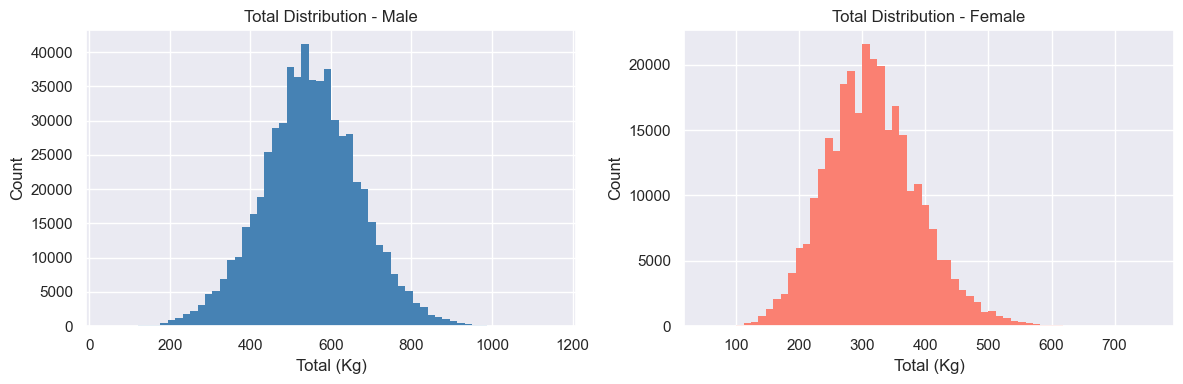

In [12]:
# Total distribution by sex
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sex in zip(axes, ['M', 'F']):
    subset = df[df['Sex'] == sex]
    ax.hist(subset['TotalKg'], bins=60, color='steelblue' if sex == 'M' else 'salmon', edgecolor='none')
    ax.set_title(f"Total Distribution - {'Male' if sex == 'M' else 'Female'}")
    ax.set_xlabel('Total (Kg)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('outputs/total_distribution.png', dpi=150)
plt.show()

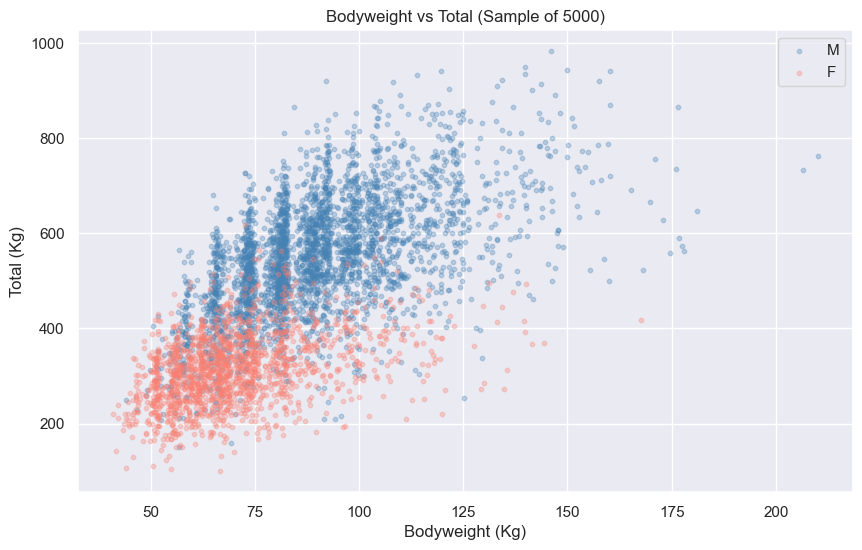

In [13]:
# Bodyweight vs total (sample 5000 points to keep it readable)
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
for sex, colour in [('M', 'steelblue'), ('F', 'salmon')]:
    subset = sample[sample['Sex'] == sex]
    plt.scatter(subset['BodyweightKg'], subset['TotalKg'], alpha=0.3, s=10, color=colour, label=sex)

plt.xlabel('Bodyweight (Kg)')
plt.ylabel('Total (Kg)')
plt.title('Bodyweight vs Total (Sample of 5000)')
plt.legend()
plt.savefig('outputs/bodyweight_vs_total.png', dpi=150)
plt.show()

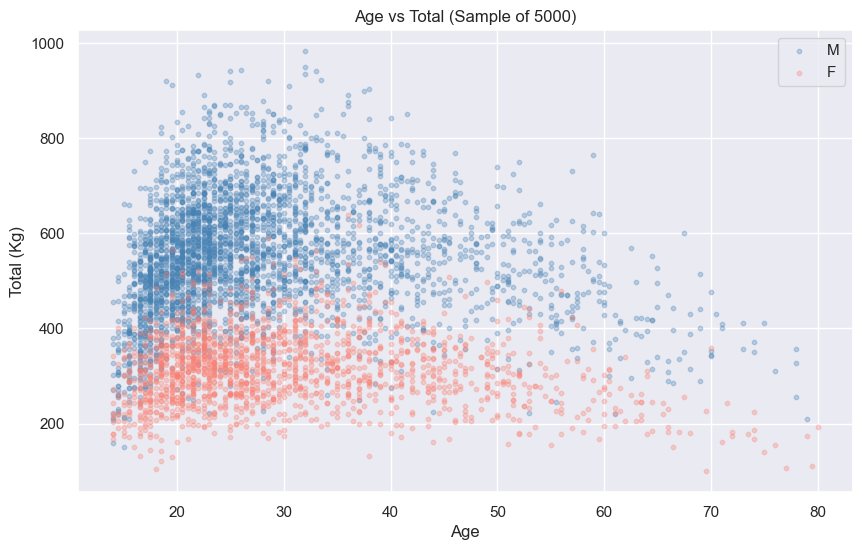

In [14]:
# Age vs Total
plt.figure(figsize=(10, 6))
for sex, colour in [('M', 'steelblue'), ('F', 'salmon')]:
    subset = sample[sample['Sex'] == sex]
    plt.scatter(subset['Age'], subset['TotalKg'], alpha=0.3, s=10, color=colour, label=sex)

plt.xlabel('Age')
plt.ylabel('Total (Kg)')
plt.title('Age vs Total (Sample of 5000)')
plt.legend()
plt.savefig('outputs/age_vs_total.png', dpi=150)
plt.show()

# Train and Evaluate model
XGBoost model evaluated with mean absolute error and R2

In [4]:
import importlib
import src.model as model_module
importlib.reload(model_module)

model, le, X_test, y_test, preds = model_module.train()

Loading clean data...
Training XGBoost model...
MAE: 61.15 kg
R²: 0.7365
Model and encoder saved.


# Model Evaluation
**Base XGBRegressor Model** (28/4/26): MAE of 61kg is large, roughly 12% of avg male total and 20% of an avg female total. R2 of 0.73 means 73% of variance in total lifted is explained, leaving 27% unexplained, which is large for a relatively simple prediction task.

The main problem is we only have 3 features to use for prediction (Age, Sex, Bodyweight), and a lifter's total is heavily influenced by other factors like training age, genetics, athletic history etc, which we don't have access to. 

We can do some feature engineering to help capture the non-linear relationships seen in the exploratory plots. Adding Bodyweight^2 and Age^2 features should help capture the logarithmic bodyweight curve and age peak seen in scatter plots without adding new data.

**Retrain with Bodyweight^2 and Age^2** (29/4/26): No meaninful difference in performance. XGBoost already captures non-linear relationships automatically (thanks Claude lol)

**THE MAIN PROBLEM** - Feature poverty. There's not enough information to predict a lifters total with any degree of accuracy just using their age, sex, and bodyweight. 

I'll try and pivot to a progression model that predicts a lifter's NEXT total using previous total, change in bodyweight since last meet, age at next meet, time between meets, and the trend in their DOTS/GL points.